# Imports

In [20]:
#test
#test on VScodes

In [21]:
import torch
print(torch.__version__)

2.2.2


In [22]:
import numpy

In [23]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

In [24]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [25]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


# Get data

In [26]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

KeyboardInterrupt: 

In [ ]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 5
n_epochs_error = 5
error_type = "L1" # "L1", "L2", or "cos"
append_image_type = 'pad' #pad, interpolate
model_type = 'im2spec'

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


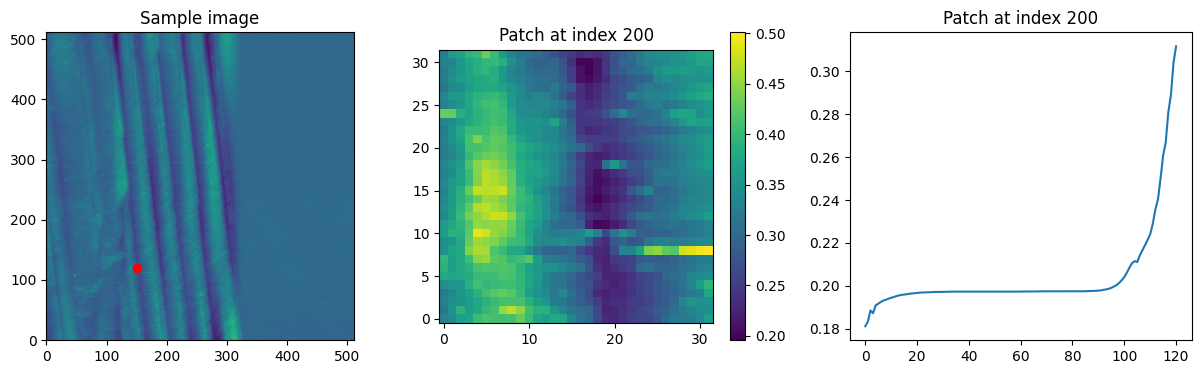

In [ ]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [ ]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

## Train/test split

In [ ]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

In [ ]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
images_all, spectra_all, swap_coordinates_all, test_size = 0.2, random_state=42
)

initial_trainsize = images_train.shape[0]
print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (819, 32, 32)
images_test shape: (205, 32, 32)
spectra_train shape: (819, 121)
spectra_test shape: (205, 121)


## Augment across scales

In [ ]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


In [ ]:
images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_train,
                                                            append_image_type=append_image_type)



images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_test,
                                                            append_image_type=append_image_type)

print("images_train shape:", images_tr_aug.shape)
print("images_test shape:", images_test_aug.shape)

Augmented images shape: (6552, 32, 32), Augmented spectra shape: (6552, 121), Augmented coordinates shape: (6552, 3)
Augmented images shape: (1640, 32, 32), Augmented spectra shape: (1640, 121), Augmented coordinates shape: (1640, 3)
images_train shape: (6552, 32, 32)
images_test shape: (1640, 32, 32)


## Model dimensions

In [ ]:

print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (8192, 32, 32)
spectra shape: (8192, 121)


# Train im2spec

## IM2SPEC model

In [ ]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'FNO':

  # FNO_im2spec mode. Trains better with interpolation based augmentation.
  imspec_model = FNO_im2spec(
      target_size=out_dim,
      latent_dim=3,
      hidden_channels=32,
      n_modes=(16, 16),
      n_layers=4,
  ).to(device)

elif model_type == 'im2spec':

  # Use this normal im2spec. Augmentation by padding works better here.
  imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

else:
  raise ValueError(f"Unknown model type: {model_type}")


In [ ]:


im2spec_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(spectra_tr_aug, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test_aug, dtype=torch.float32),
    torch.tensor(spectra_test_aug, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [03:08<12:34, 188.51s/it, train_loss=0.0434, val_loss=0.0333]


KeyboardInterrupt: 

# Estimate error

In [ ]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_tr_aug, spectra_tr_aug, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)


print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)


# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

error_mean shape: (6552,)
error_vector shape: (6552, 121)
error_targets shape: (6552, 1)


## Train error model

100%|██████████| 100/100 [00:31<00:00,  3.22it/s, train_loss=0.0002, val_loss=0.0002]


error model final train loss: 0.00015400921438413206
error model final val loss: 0.00023763918060077622


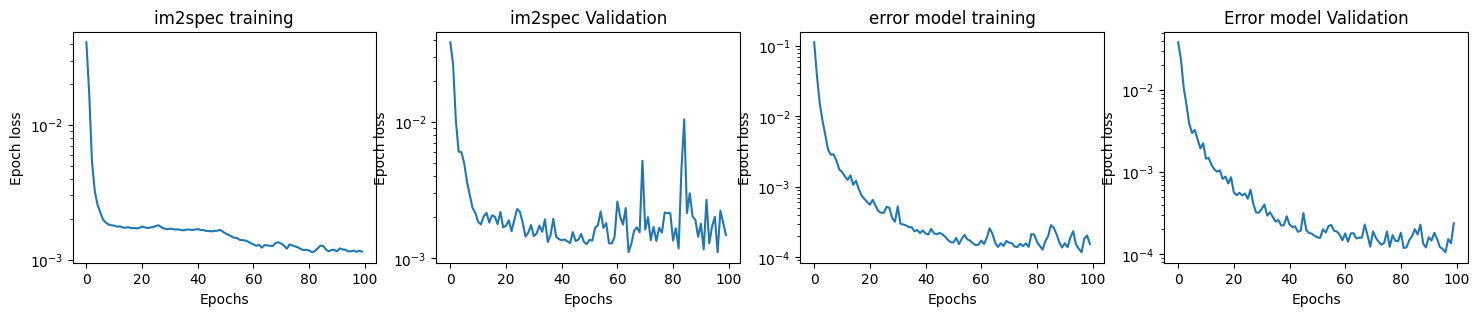

In [ ]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

# Predict all errors

In [ ]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
predicted_errors = np.clip(predicted_errors, 0, None)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (8192,)
predicted_errors range: 0.0 0.11693055927753448


## Acquisition function

In [ ]:
#from nnerror.training_functions import distance_acq_fn
#from nnerror.plot_functions import plot_error_prediction, plot_spectra


#beta=0 is explotation. aq_fn is inverse to errors
#aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
#print(aq_fn.shape)


NameError: name 'predicted_errors' is not defined

# Variance with test size

# Visualize acquisition results

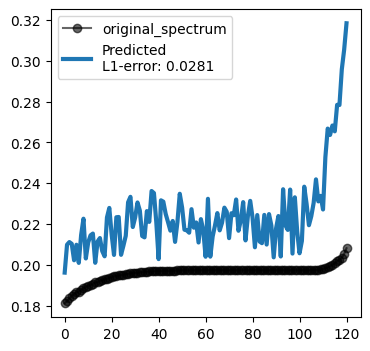

In [ ]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = scale_coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1], error_type=error_type)
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean())

## 3D error and acquisition view

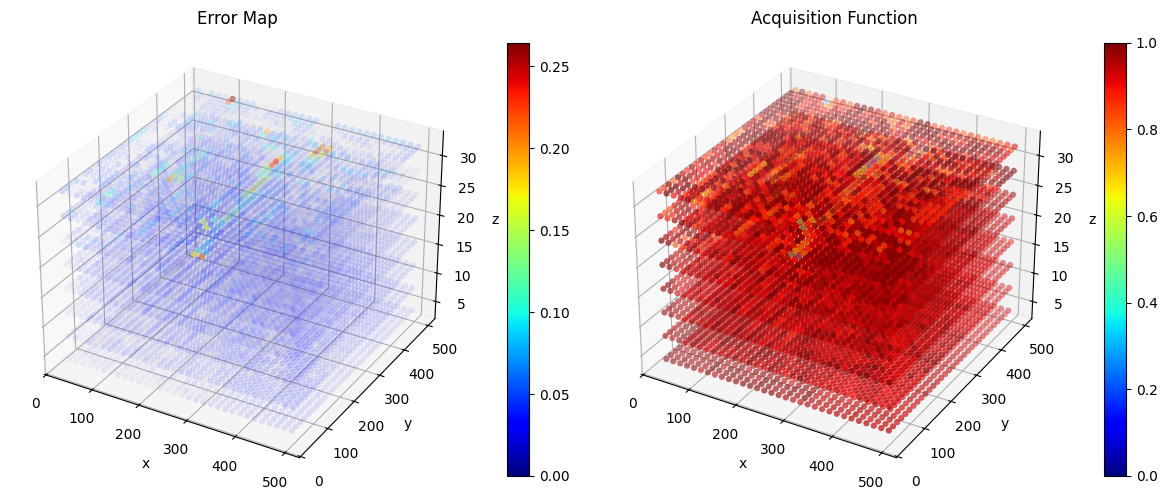

In [ ]:
plot_error_prediction_3d(predicted_errors, aq_fn, scale_coordinates, aq_ind, alpha_scale=True,
                         colormap="jet", )

## Scale-specific error maps

In [ ]:
plot_scale_slider(scale_coordinates, predicted_errors, aq_fn, colormap="jet")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Scale', max=7), Output()), _dom…

<function nnerror.plot_functions.plot_scale_slider.<locals>._draw_by_index(scale_index)>

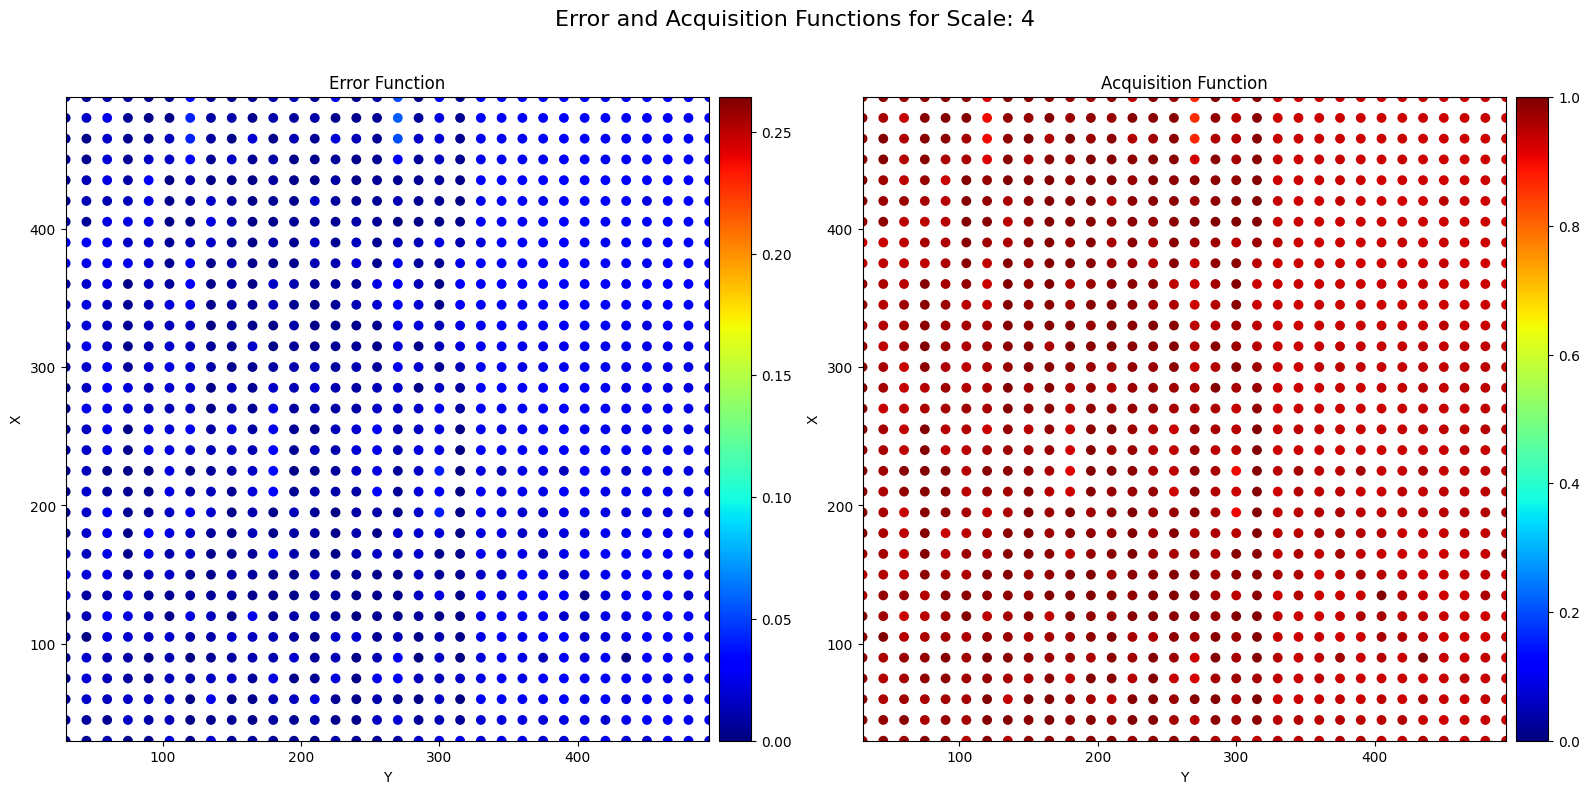

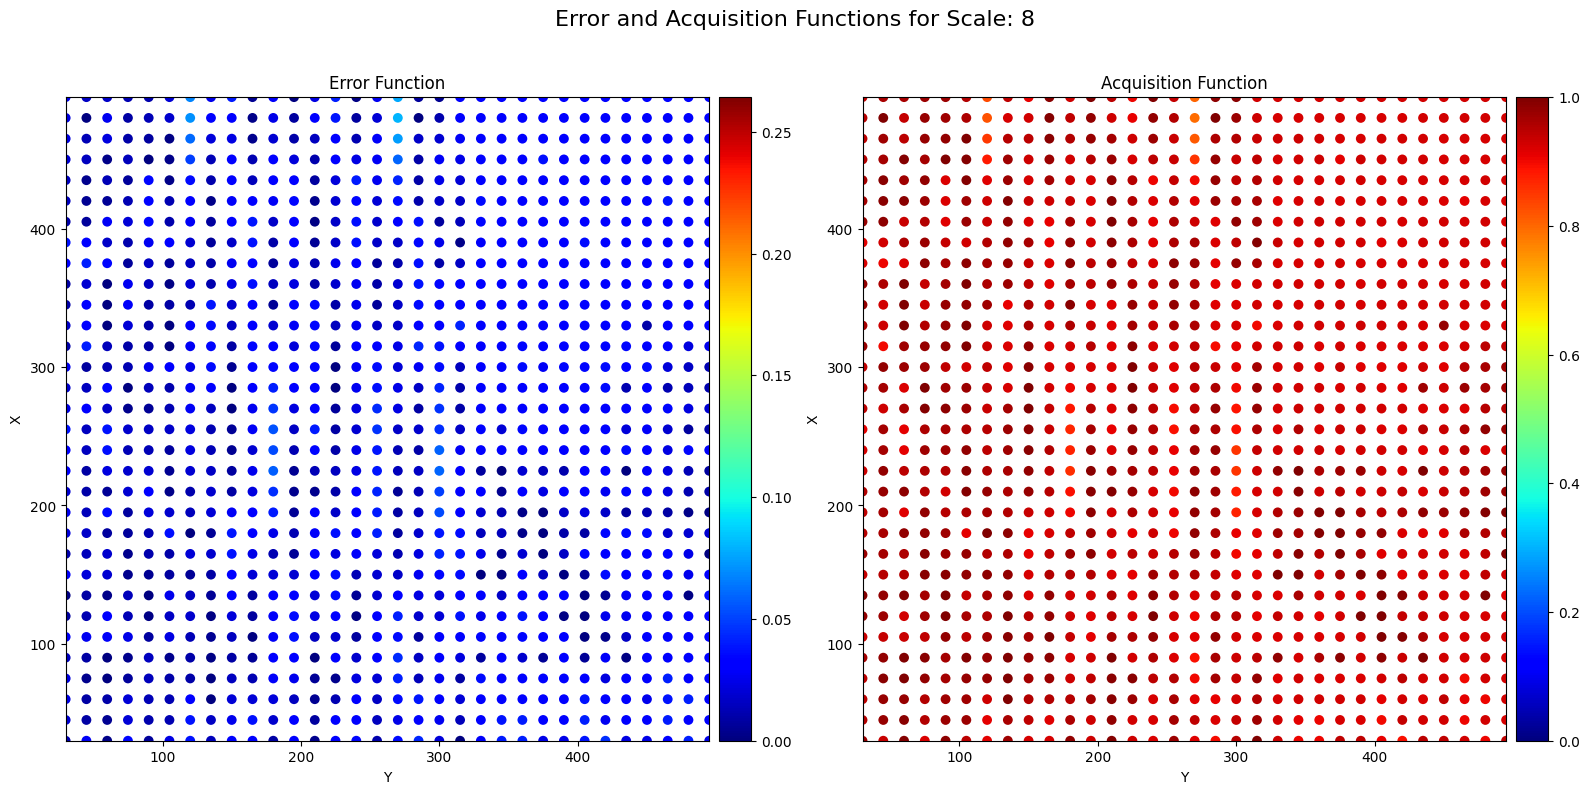

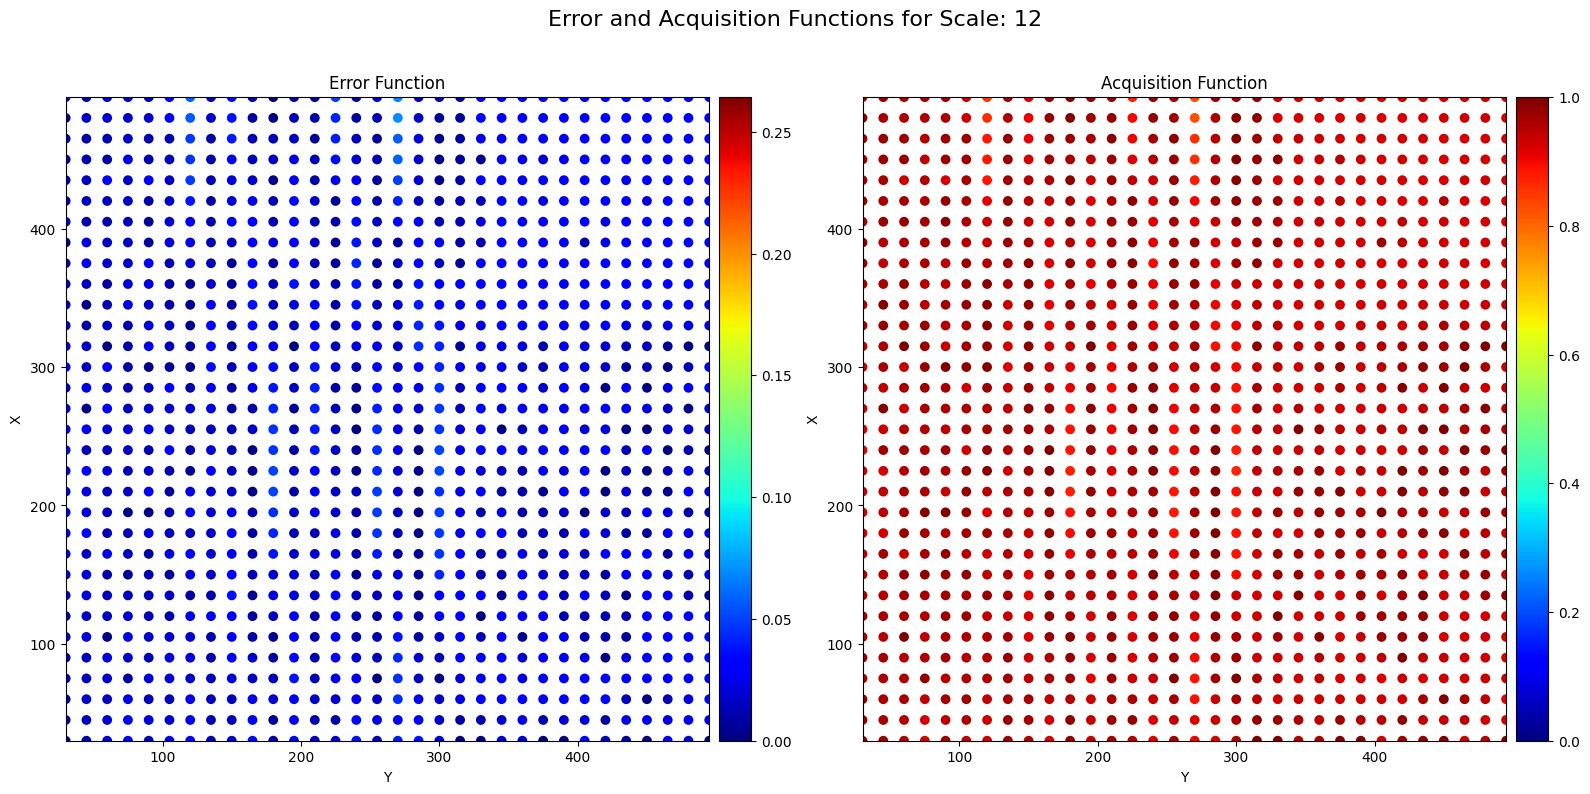

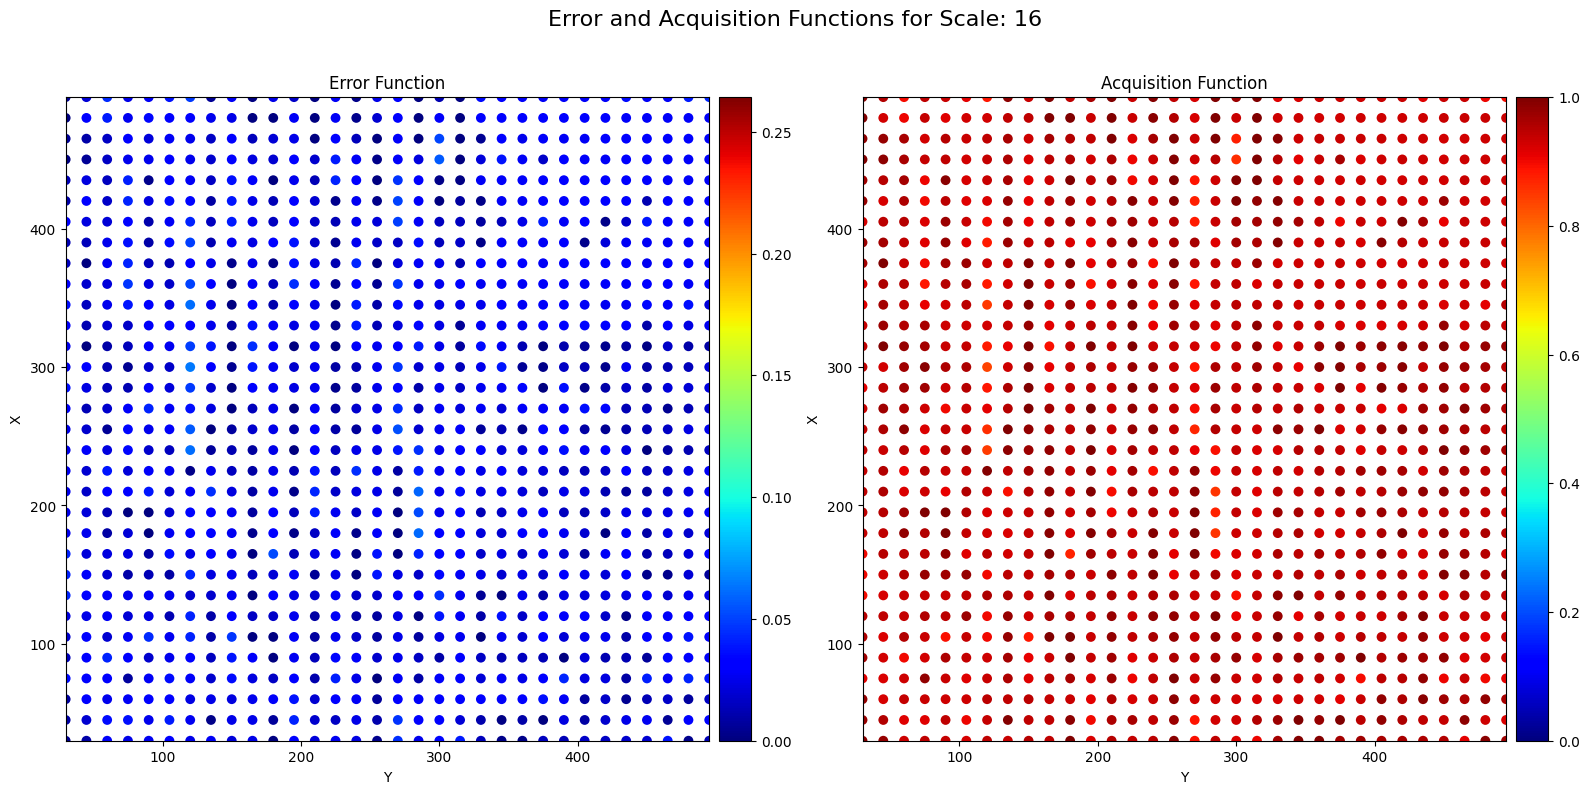

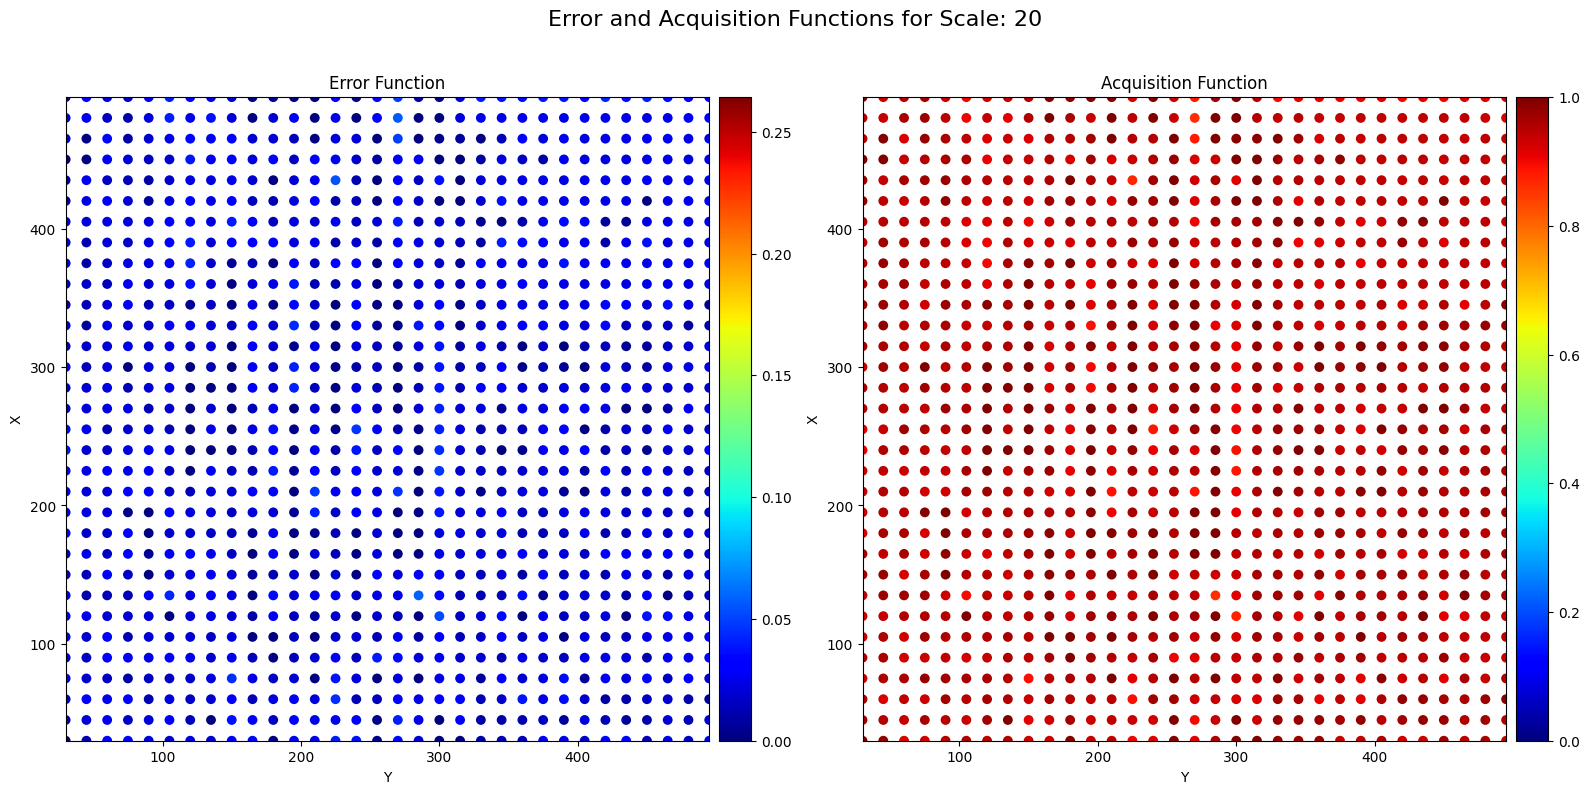

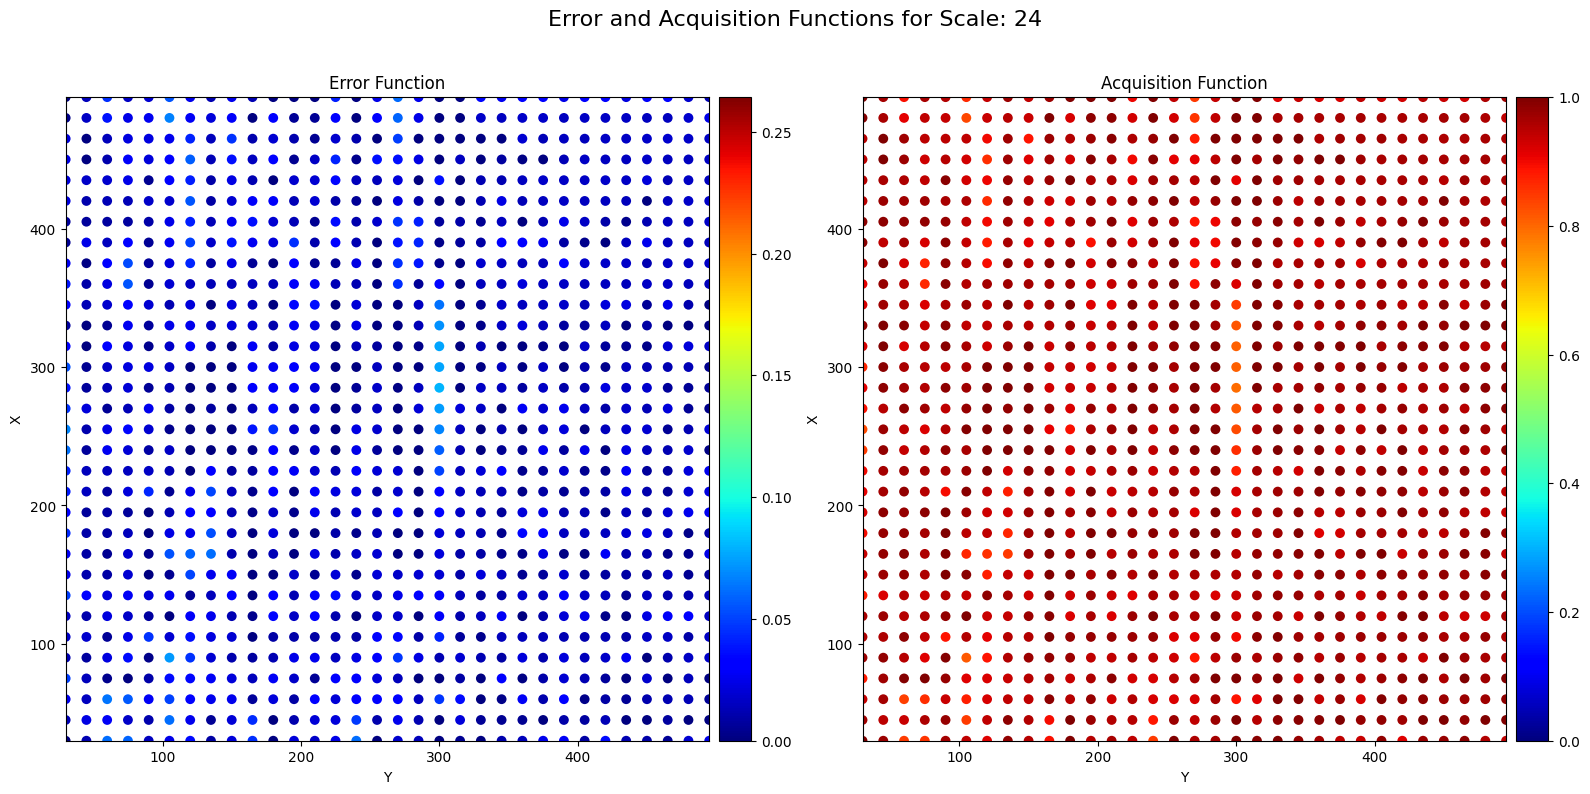

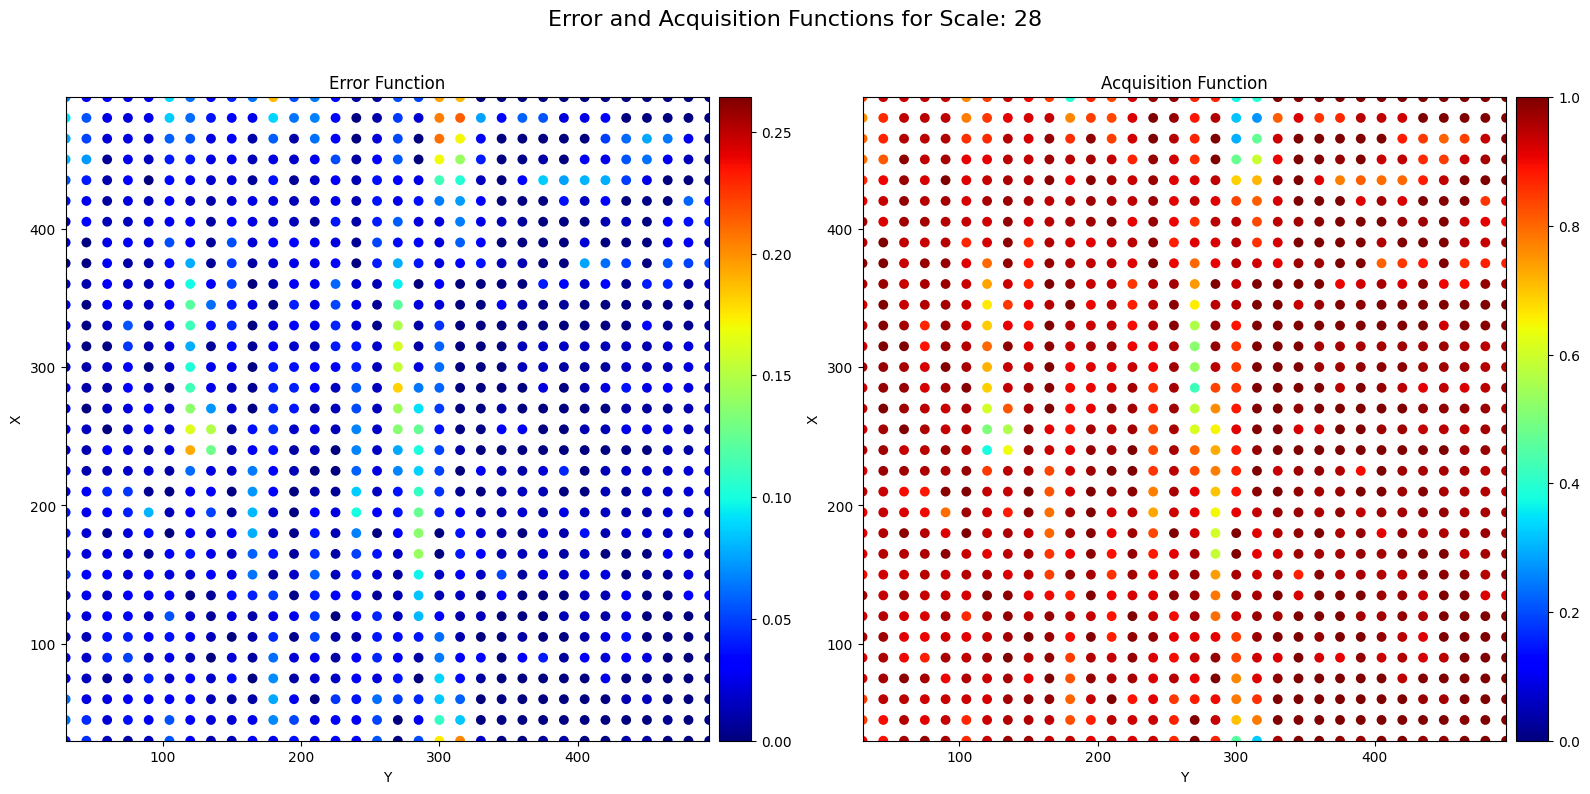

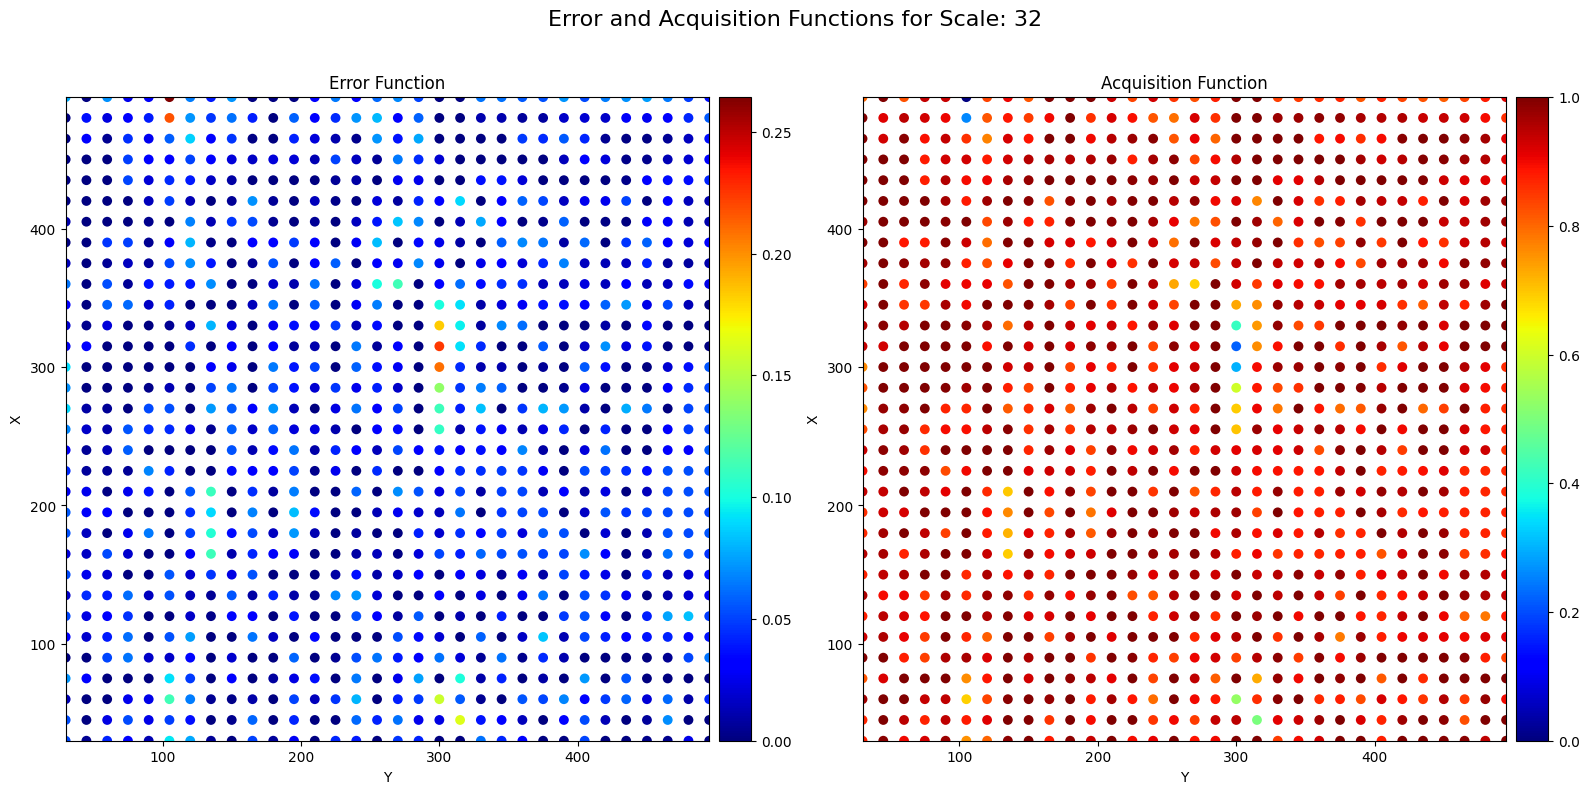

In [ ]:
unique_scales = np.unique(scale_coordinates[:, 2])

# min/max for color scaling
global_error_min = predicted_errors.min()
global_error_max = predicted_errors.max()
global_aq_fn_min = aq_fn.min()
global_aq_fn_max = aq_fn.max()

#  min/max for X and Y coordinates across scales
global_x_min = scale_coordinates[:, 0].min()
global_x_max = scale_coordinates[:, 0].max()
global_y_min = scale_coordinates[:, 1].min()
global_y_max = scale_coordinates[:, 1].max()

# loop through scales
for s in unique_scales:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f'Error and Acquisition Functions for Scale: {int(s)}', fontsize=16)

    scale_mask = scale_coordinates[:, 2] == s
    coords_for_scale = scale_coordinates[scale_mask, :2] # x, y coordinates
    errors_for_scale = predicted_errors[scale_mask]
    aq_fn_for_scale = aq_fn[scale_mask]

    # error plot
    sc1 = axes[0].scatter(coords_for_scale[:, 0], coords_for_scale[:, 1],
                          c=errors_for_scale, cmap='jet', s=50, marker='o', edgecolors='none',
                          vmin=global_error_min, vmax=global_error_max)
    axes[0].set_title('Error Function')
    axes[0].set_xlabel('Y')
    axes[0].set_ylabel('X')
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].set_xlim(global_x_min, global_x_max)
    axes[0].set_ylim(global_y_min, global_y_max)
    divider1 = make_axes_locatable(axes[0])
    cax1 = divider1.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc1, cax=cax1)

    # aqn function plot
    sc2 = axes[1].scatter(coords_for_scale[:, 0], coords_for_scale[:, 1],
                          c=aq_fn_for_scale, cmap='jet', s=50, marker='o', edgecolors='none',
                          vmin=global_aq_fn_min, vmax=global_aq_fn_max)
    axes[1].set_title('Acquisition Function')
    axes[1].set_xlabel('Y')
    axes[1].set_ylabel('X')
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].set_xlim(global_x_min, global_x_max)
    axes[1].set_ylim(global_y_min, global_y_max)
    divider2 = make_axes_locatable(axes[1])
    cax2 = divider2.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc2, cax=cax2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

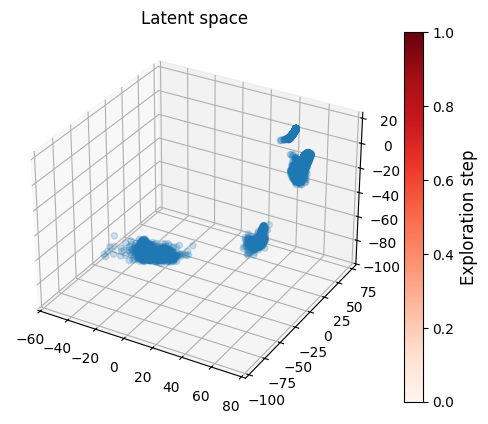

In [ ]:
output_type = 'latent'
posterior_spectra = predict_posterior(imspec_model, images, output_type = output_type)
posterior_trainset = predict_posterior(imspec_model, images_train, output_type = output_type)
plot_latent_space(posterior_spectra, posterior_trainset[initial_trainsize:],lat_order = [0, 1, 2])

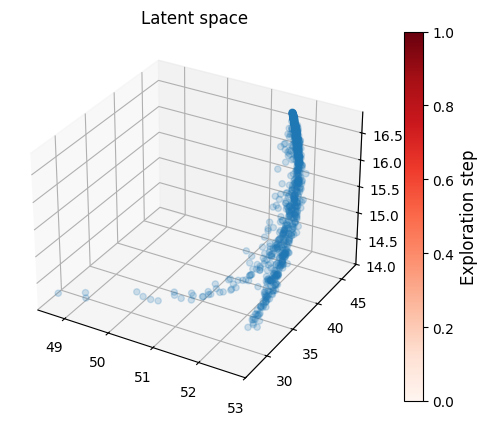

(1024,)


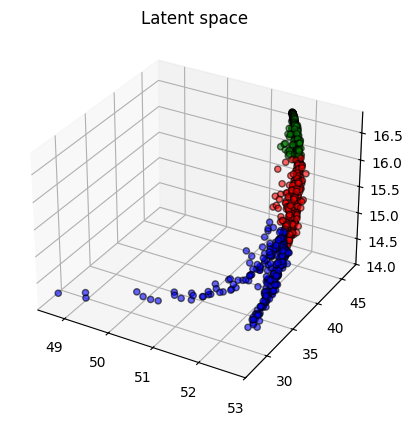

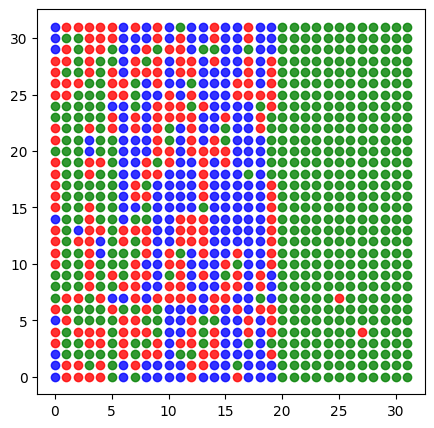

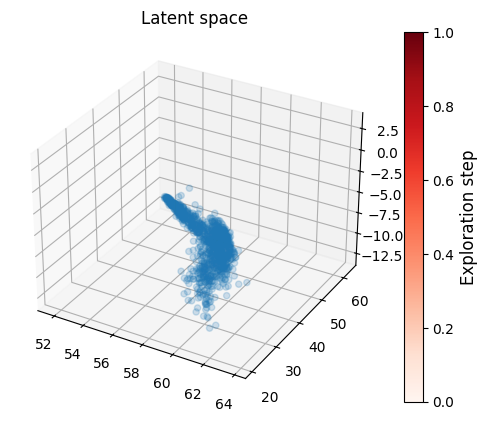

(1024,)


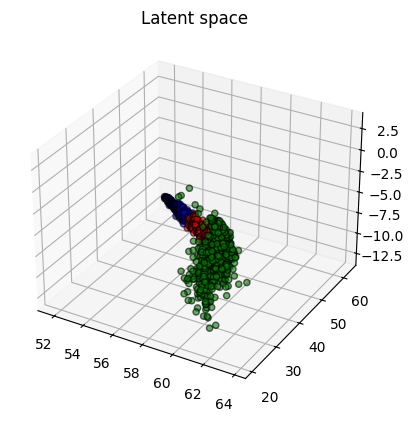

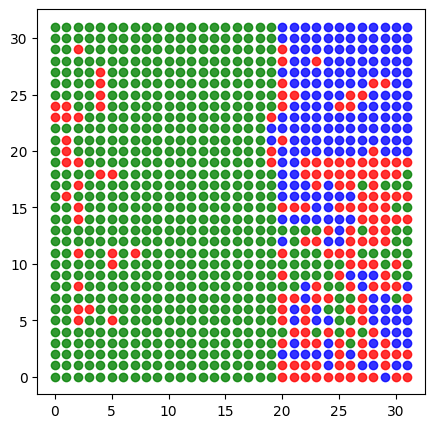

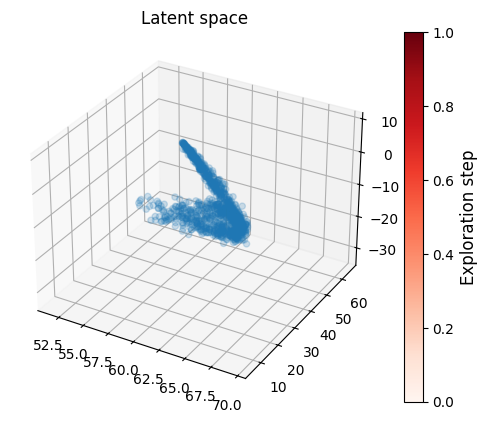

(1024,)


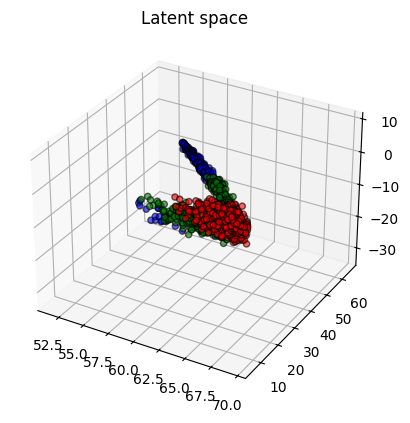

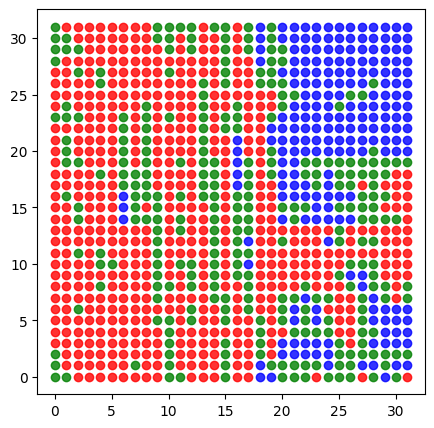

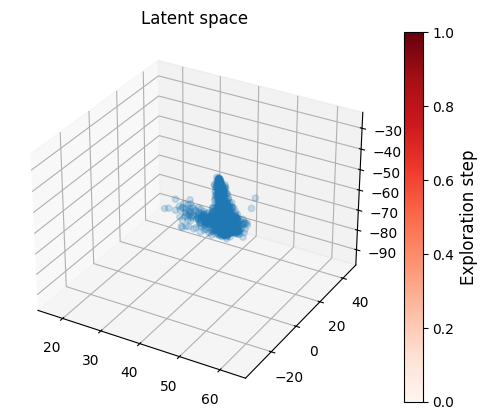

(1024,)


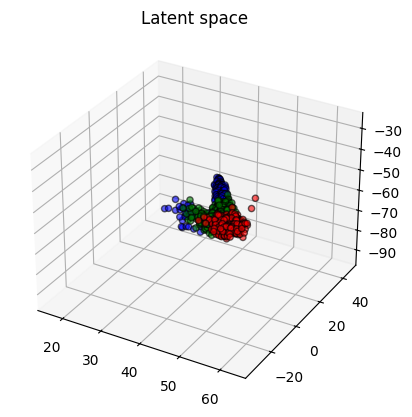

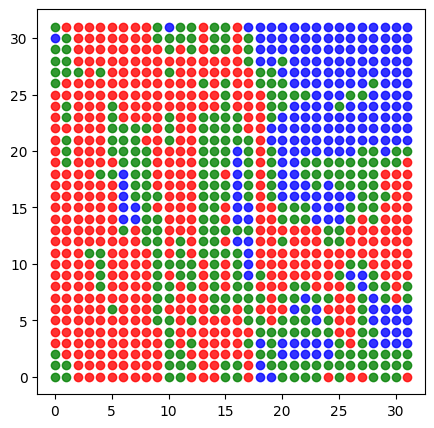

In [ ]:
for s in unique_scales[::2]:
  scale_mask = scale_coordinates[:, 2] == s
  latent_space_scaled = posterior_spectra[scale_mask]

  # Latent space plot
  plot_latent_space(latent_space_scaled, posterior_trainset[initial_trainsize:], lat_order = [0,1,2])

  # Clustered latent space plot
  cluster_latent_space(latent_space_scaled, lat_order = [0, 1, 2], n_clusters = 3)


In [ ]:
#cluster_latent_space(posterior_spectra, lat_order = [0, 1, 2],  n_clusters = 3) # keep n_clusters < 5

In [ ]:
def split_augment(train_size, random_state = 42):

  images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
  images_all, spectra_all, swap_coordinates_all, train_size = train_size, random_state=42)



  images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_train,
                                                              append_image_type=append_image_type)



  images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_test,
                                                              append_image_type=append_image_type)

  return images_tr_aug, images_test_aug, spectra_tr_aug, spectra_test_aug


Testing with test size: 0.1
Augmented images shape: (816, 32, 32), Augmented spectra shape: (816, 121), Augmented coordinates shape: (816, 3)
Augmented images shape: (7376, 32, 32), Augmented spectra shape: (7376, 121), Augmented coordinates shape: (7376, 3)


100%|██████████| 5/5 [02:44<00:00, 32.85s/it, train_loss=0.0027, val_loss=0.0045]


  Error targets train shape: (816, 1)
  Error targets test shape: (7376, 1)


100%|██████████| 5/5 [00:27<00:00,  5.46s/it, train_loss=0.0003, val_loss=0.0003]


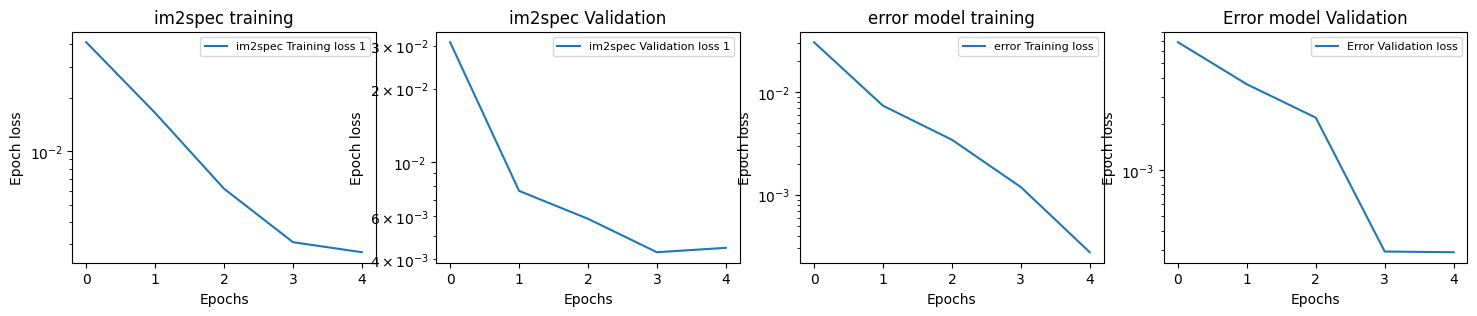

Error Model Train Loss (from training history): 0.0003, Val Loss (from training history): 0.0003

Testing with test size: 0.4
Augmented images shape: (3272, 32, 32), Augmented spectra shape: (3272, 121), Augmented coordinates shape: (3272, 3)
Augmented images shape: (4920, 32, 32), Augmented spectra shape: (4920, 121), Augmented coordinates shape: (4920, 3)


100%|██████████| 5/5 [05:21<00:00, 64.39s/it, train_loss=0.0024, val_loss=0.0034]


  Error targets train shape: (3272, 1)
  Error targets test shape: (4920, 1)


100%|██████████| 5/5 [03:35<00:00, 43.15s/it, train_loss=0.0095, val_loss=0.0147]


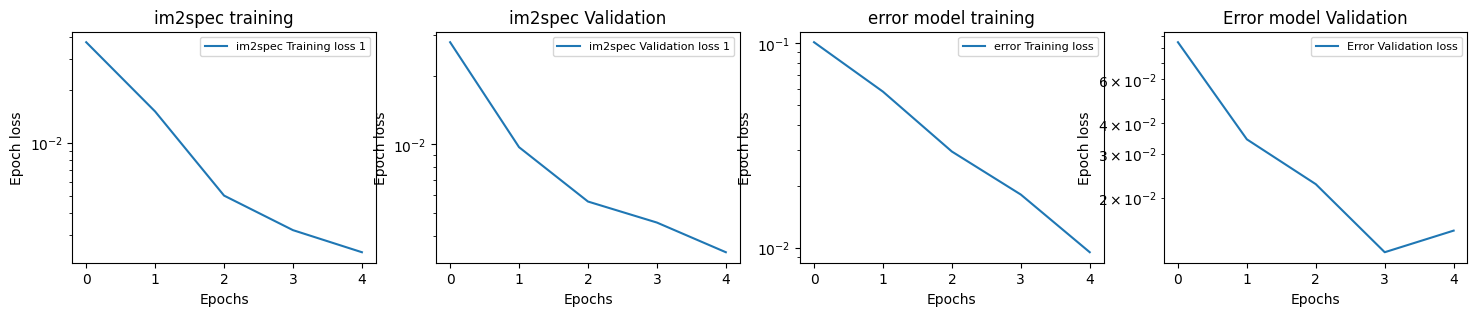

Error Model Train Loss (from training history): 0.0095, Val Loss (from training history): 0.0147

Testing with test size: 0.7000000000000001
Augmented images shape: (5728, 32, 32), Augmented spectra shape: (5728, 121), Augmented coordinates shape: (5728, 3)
Augmented images shape: (2464, 32, 32), Augmented spectra shape: (2464, 121), Augmented coordinates shape: (2464, 3)


100%|██████████| 5/5 [07:28<00:00, 89.78s/it, train_loss=0.0032, val_loss=0.0050] 


  Error targets train shape: (5728, 1)
  Error targets test shape: (2464, 1)


100%|██████████| 5/5 [03:40<00:00, 44.07s/it, train_loss=0.0020, val_loss=0.0016]


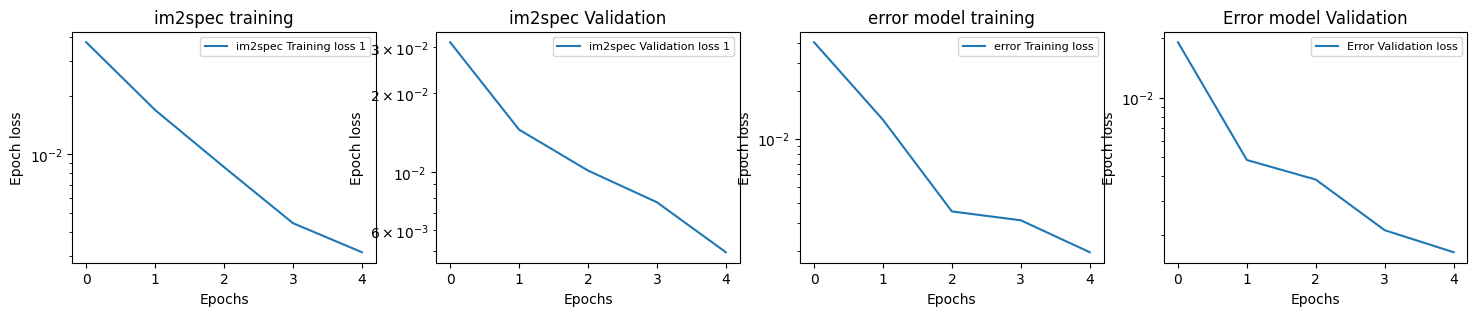

Error Model Train Loss (from training history): 0.0020, Val Loss (from training history): 0.0016


In [ ]:
train_sizes = np.arange(0.1, 1, 0.3)

im2spec_train_losses = []
im2spec_val_losses = []
im2spec_test_losses = []

error_train_losses = []
error_val_losses = []

for ts in train_sizes:



    print(f"\nTesting with test size: {ts}")

    #original_images, original_spectra, original_coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS, coordinate_step = 15, image_norm=False, spectra_norm = False)
    images_train_ts, images_test_ts, spectra_train_ts, spectra_test_ts = split_augment(ts)


    if images_train_ts.shape[0] == 0 or images_test_ts.shape[0] == 0:
        print(f"Skipping test size {ts} due to insufficient training data.")
        continue

    # Train im2spec model on this train/test split
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    imspec_model_ts = FNO_im2spec(
        target_size=out_dim,
        latent_dim=3,
        hidden_channels=32,
        n_modes=(16, 16),
        n_layers=4,
    ).to(device)

    #imspec_model_ts = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

    impsec_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(spectra_train_ts, dtype=torch.float32),
    )
    impsec_val_dataset_ts = TensorDataset(
        torch.tensor(images_test_ts, dtype=torch.float32),
        torch.tensor(spectra_test_ts, dtype=torch.float32),
    )

    im2spec_model_ts, im2spec_train_loss_ts, im2spec_val_loss_ts = train_model(
        imspec_model_ts,
        impsec_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_im2spec,
        partial_train=False,
        val_dataset=impsec_val_dataset_ts,
    )
    im2spec_train_losses.append(im2spec_train_loss_ts)
    im2spec_val_losses.append(im2spec_val_loss_ts)

    imspec_model_ts.eval()
    with torch.no_grad():
        x_test_ts = torch.tensor(images_test_ts, dtype=torch.float32, device=device)
        y_test_ts = torch.tensor(spectra_test_ts, dtype=torch.float32, device=device)
        test_pred_ts = imspec_model_ts.predict(x_test_ts)
        im2spec_test_loss_ts = torch.nn.functional.mse_loss(test_pred_ts, y_test_ts).item()
    im2spec_test_losses.append(im2spec_test_loss_ts)

    # Train error model
    error_mean_ts, _, _ = err_estimation(imspec_model_ts, images_train_ts, spectra_train_ts, error_type=error_type)
    error_targets_ts = error_mean_ts.astype(np.float32).reshape(-1, 1)

    # Add error estimation for the test set
    error_mean_test_ts, _, _ = err_estimation(imspec_model_ts, images_test_ts, spectra_test_ts, error_type=error_type)
    error_targets_test_ts = error_mean_test_ts.astype(np.float32).reshape(-1, 1)

    print(f"  Error targets train shape: {error_targets_ts.shape}")
    print(f"  Error targets test shape: {error_targets_test_ts.shape}")

    latent_dim_ts = imspec_model_ts.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model_ts = CustomDecoder(encoder=imspec_model_ts.encoder, embed_dim=latent_dim_ts, target_size=1).to(device)

    error_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(error_targets_ts, dtype=torch.float32),
    )

    error_model_ts, error_train_loss_ts, error_val_loss_ts = train_model(
        error_model_ts,
        error_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
    )

    plot_training_loss([im2spec_train_loss_ts], [im2spec_val_loss_ts], error_train_loss_ts, error_val_loss_ts)

    print(f"Error Model Train Loss (from training history): {error_train_loss_ts[-1]:.4f}, Val Loss (from training history): {error_val_loss_ts[-1]:.4f}")

    # Append all losses to the lists for box plotting
    error_train_losses.append(error_train_loss_ts)
    error_val_losses.append(error_val_loss_ts)

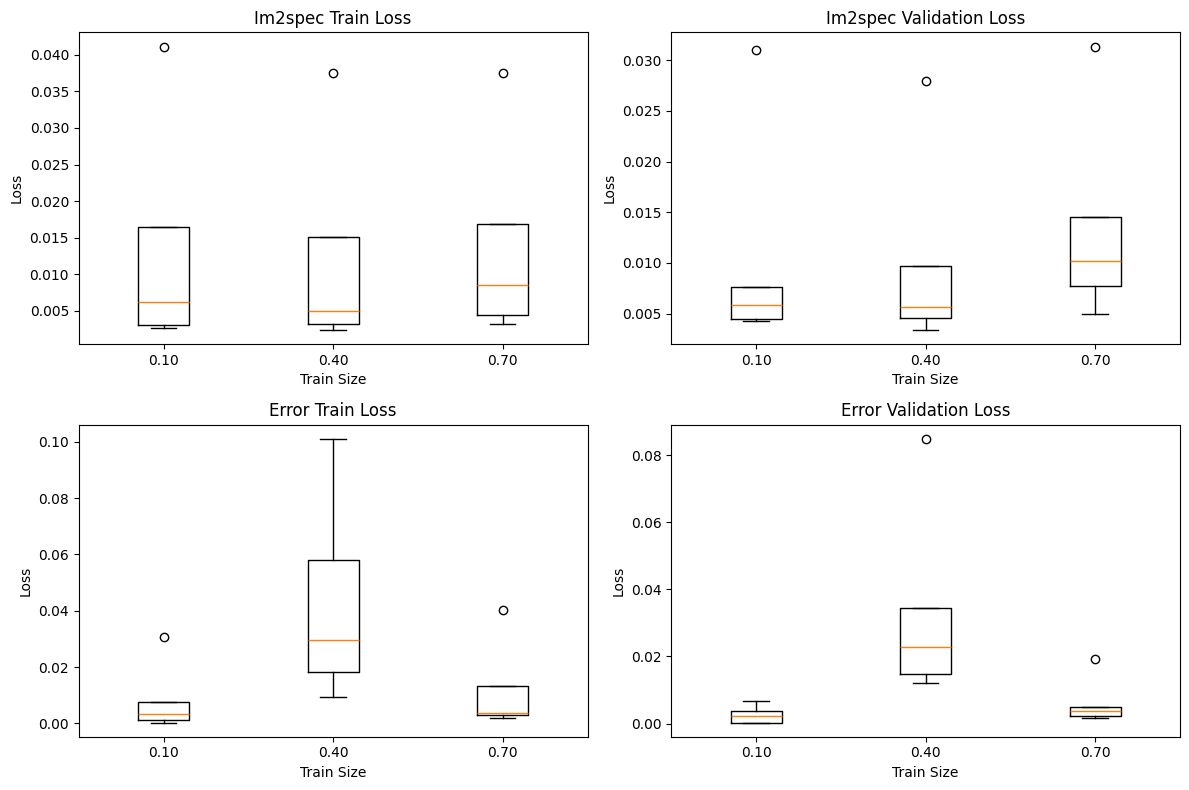

In [28]:
#plot_training_loss(im2spec_train_losses, im2spec_val_losses, error_train_losses, error_val_losses)

# Plot bar charts on separate axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].boxplot(im2spec_train_losses)
axes[0, 0].set_title("Im2spec Train Loss")
axes[0, 0].set_xlabel(f"Train Size")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_xticks(range(1, len(train_sizes) + 1))
axes[0, 0].set_xticklabels([f"{ts:.2f}" for ts in train_sizes])

axes[0, 1].boxplot(im2spec_val_losses)
axes[0, 1].set_title("Im2spec Validation Loss")
axes[0, 1].set_xlabel(f"Train Size")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_xticks(range(1, len(train_sizes) + 1))
axes[0, 1].set_xticklabels([f"{ts:.2f}" for ts in train_sizes])

axes[1, 0].boxplot(error_train_losses)
axes[1, 0].set_title("Error Train Loss")
axes[1, 0].set_xlabel(f"Train Size")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].set_xticks(range(1, len(train_sizes) + 1))
axes[1, 0].set_xticklabels([f"{ts:.2f}" for ts in train_sizes])

axes[1, 1].boxplot(error_val_losses)
axes[1, 1].set_title("Error Validation Loss")
axes[1, 1].set_xlabel(f"Train Size")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].set_xticks(range(1, len(train_sizes) + 1))
axes[1, 1].set_xticklabels([f"{ts:.2f}" for ts in train_sizes])

plt.tight_layout()
plt.show()